✅ 2D Asset kaydedildi: C:\Users\ozhan\Desktop\The-Mathematical-Lab-Bench-main\The-Mathematical-Lab-Bench-main\assets\36_chisq_2d.png
✅ 3D Asset kaydedildi: C:\Users\ozhan\Desktop\The-Mathematical-Lab-Bench-main\The-Mathematical-Lab-Bench-main\assets\36_chisq_3d.png


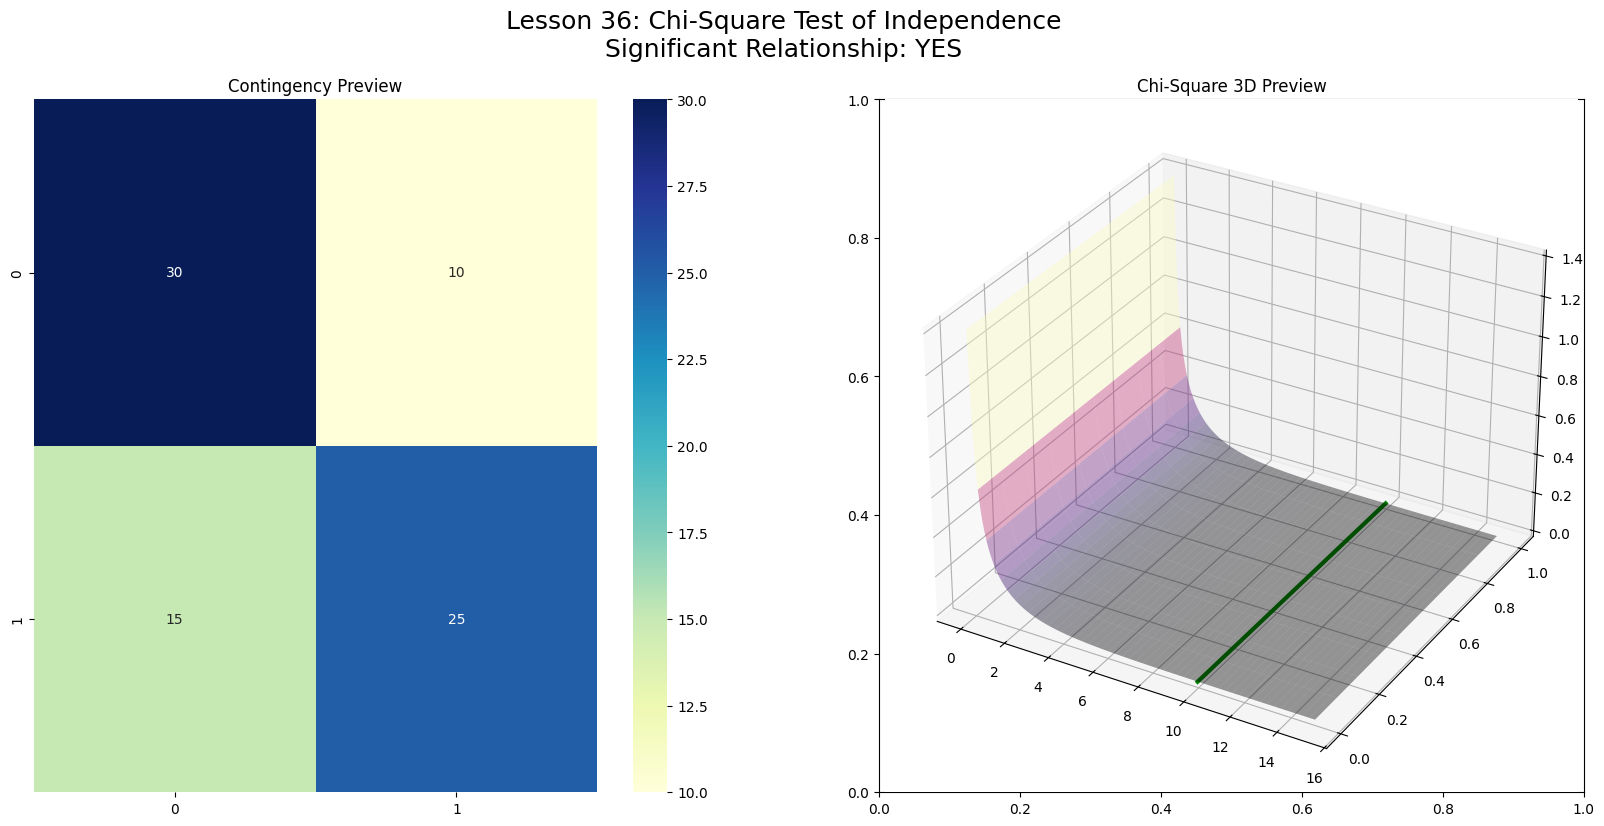

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import scipy.stats as stats
import seaborn as sns
import os

def run_chisq_master():
    # --- YOL AYARI (Ph.D. Disiplini) ---
    asset_path = r'../../../assets'
    if not os.path.exists(asset_path):
        os.makedirs(asset_path)

    # 1. Veri Üretimi (Kontenjans Tablosu: Örn. Tercih A vs Tercih B)
    # Satırlar: Gruplar, Sütunlar: Tercihler
    observed = np.array([[30, 10], [15, 25]]) 
    
    # Chi-Square Hesaplama
    chi2, p_val, dof, expected = stats.chi2_contingency(observed)

    # --- 📸 ASSET 1: SADECE 2D GRAFİK (36_chisq_2d.png) ---
    fig2d = plt.figure(figsize=(10, 7))
    ax2d = fig2d.add_subplot(111)
    
    sns.heatmap(observed, annot=True, fmt="d", cmap="YlGnBu", 
                xticklabels=['Option X', 'Option Y'], yticklabels=['Group 1', 'Group 2'], ax=ax2d)
    ax2d.set_title(f"Chi-Square Contingency Table (Observed)\nChi2: {chi2:.2f} | P-Value: {p_val:.5f}")
    
    plt.savefig(os.path.join(asset_path, '36_chisq_2d.png'), dpi=300)
    print(f"✅ 2D Asset kaydedildi: {asset_path}\\36_chisq_2d.png")
    plt.close(fig2d)

    # --- 📸 ASSET 2: SADECE 3D GRAFİK (36_chisq_3d.png) ---
    fig3d = plt.figure(figsize=(10, 8))
    ax3d = fig3d.add_subplot(111, projection='3d')
    
    x = np.linspace(0, 15, 200)
    y_depth = np.linspace(0, 1, 10)
    X_grid, Y_grid = np.meshgrid(x, y_depth)
    Z_grid = stats.chi2.pdf(X_grid, df=dof)

    # Ana Dağılım Yüzeyi
    ax3d.plot_surface(X_grid, Y_grid, Z_grid, cmap='magma', alpha=0.6, edgecolor='none')
    
    # Red Bölgesi (Kritik bölge Alpha=0.05)
    chi_crit = stats.chi2.ppf(1 - 0.05, df=dof)
    x_red = x[x > chi_crit]
    if len(x_red) > 0:
        X_r, Y_r = np.meshgrid(x_red, y_depth)
        ax3d.plot_surface(X_r, Y_r, stats.chi2.pdf(X_r, df=dof), color='red', alpha=0.8)
    
    # Gözlemlenen Chi2 (Yeşil Bayrak)
    ax3d.plot([chi2, chi2], [0, 1], [0, stats.chi2.pdf(chi2, df=dof)], color='green', lw=5, label=f'Observed Chi2={chi2:.2f}')

    ax3d.set_title("3D Chi-Square Distribution Decision Space")
    ax3d.set_xlabel('Chi-Square Value')
    ax3d.legend()
    
    plt.savefig(os.path.join(asset_path, '36_chisq_3d.png'), dpi=300)
    print(f"✅ 3D Asset kaydedildi: {asset_path}\\36_chisq_3d.png")
    plt.close(fig3d)

    # --- 🖥️ DASHBOARD (Preview) ---
    fig_dash, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))
    sns.heatmap(observed, annot=True, ax=ax1, cmap="YlGnBu")
    ax1.set_title("Contingency Preview")
    
    ax2 = fig_dash.add_subplot(122, projection='3d')
    ax2.plot_surface(X_grid, Y_grid, Z_grid, cmap='magma', alpha=0.4)
    ax2.plot([chi2, chi2], [0, 1], [0, stats.chi2.pdf(chi2, df=dof)], color='green', lw=3)
    ax2.set_title("Chi-Square 3D Preview")
    
    plt.suptitle(f"Lesson 36: Chi-Square Test of Independence\nSignificant Relationship: {'YES' if p_val < 0.05 else 'NO'}", fontsize=18)
    plt.show()

if __name__ == "__main__":
    run_chisq_master()